# 02 - Time Series Preparation

Convert one store-item demand series into supervised learning sequences for an LSTM.

We use the previous 30 days to predict the following day.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

train = pd.read_csv("../data/train.csv", parse_dates=["date"])

STORE_ID = 1
ITEM_ID = 1
LOOKBACK = 30

series = (
    train[(train["store"] == STORE_ID) & (train["item"] == ITEM_ID)]
    .sort_values("date")
    [["date", "sales"]]
    .reset_index(drop=True)
)

series.head()

,date,sales
0,2013-01-01,13
1,2013-01-02,11
2,2013-01-03,14
3,2013-01-04,13
4,2013-01-05,10


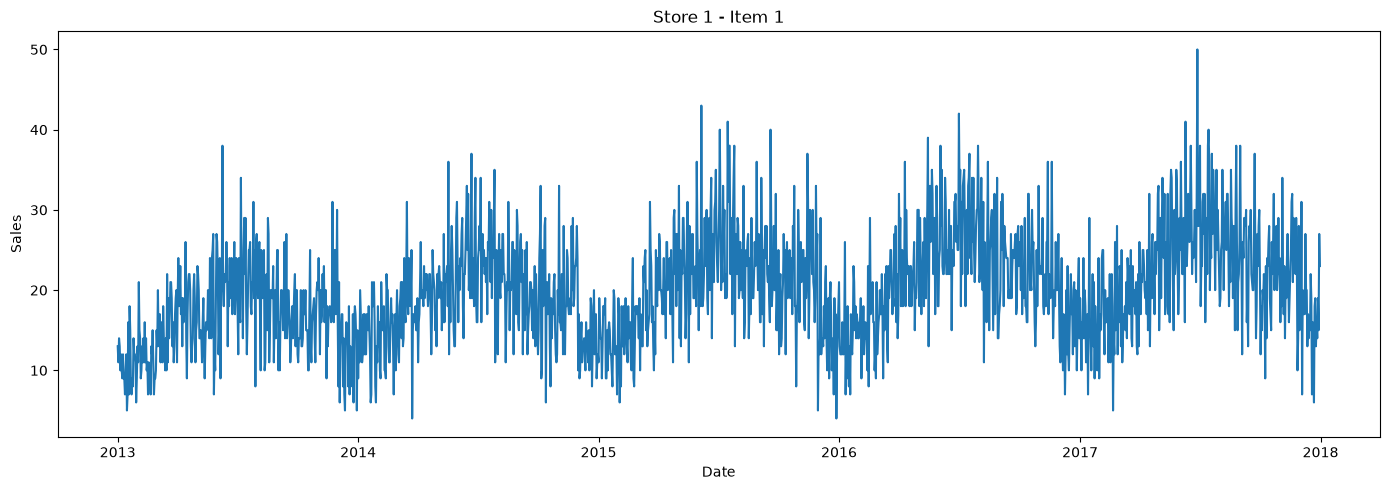

In [2]:
plt.figure(figsize=(14, 5))
plt.plot(series["date"], series["sales"])
plt.title(f"Store {STORE_ID} - Item {ITEM_ID}")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [3]:
# Time-aware split:
# 70% training, 15% validation, 15% test.

values = series["sales"].values.astype("float32").reshape(-1, 1)

n = len(values)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_values = values[:train_end]
val_values = values[train_end:val_end]
test_values = values[val_end:]

print("Train:", len(train_values))
print("Validation:", len(val_values))
print("Test:", len(test_values))

Train: 1278
Validation: 274
Test: 274


In [4]:
scaler = MinMaxScaler()
scaler.fit(train_values)

scaled_all = scaler.transform(values)
scaled_train = scaled_all[:train_end]
scaled_val = scaled_all[train_end:val_end]
scaled_test = scaled_all[val_end:]

def make_sequences(values, lookback=30):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i-lookback:i, 0])
        y.append(values[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(scaled_train, LOOKBACK)

# For validation/test, prepend the preceding observations so that
# the first validation/test prediction still has a full lookback window.
val_input = scaled_all[train_end-LOOKBACK:val_end]
test_input = scaled_all[val_end-LOOKBACK:]

X_val, y_val = make_sequences(val_input, LOOKBACK)
X_test, y_test = make_sequences(test_input, LOOKBACK)

X_train = X_train.reshape((-1, LOOKBACK, 1))
X_val = X_val.reshape((-1, LOOKBACK, 1))
X_test = X_test.reshape((-1, LOOKBACK, 1))

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (1248, 30, 1)
X_val: (274, 30, 1)
X_test: (274, 30, 1)


In [5]:
# A simple seasonal-naive reference is useful for interviews.
# It predicts today's demand using demand from seven days ago.

actual_test = values[val_end:].flatten()
seasonal_naive = values[val_end-7:-7].flatten()

baseline_mae = np.mean(np.abs(actual_test - seasonal_naive))
baseline_rmse = np.sqrt(np.mean((actual_test - seasonal_naive) ** 2))

print("Seasonal-naive MAE:", round(baseline_mae, 3))
print("Seasonal-naive RMSE:", round(baseline_rmse, 3))

Seasonal-naive MAE: 5.493
Seasonal-naive RMSE: 6.847


## Why this split matters

A random `train_test_split` is not appropriate for the final forecasting experiment because it can place future observations in the training set.

The chronological split better represents the real task:

```text
Past ────────────────> Future
Train → Validation → Test
```

The scaler is fitted only on the training period to avoid leaking information from the future.